# Análise de EOF em perfis de velocidade do som — GLORYS (1993–2026)

Adaptado da metodologia de:

> Radhakrishnan, S. & Anilkumar, K. (2024). *Inversion for water column sound speed profile from acoustic travel times using empirical orthogonal functions.* J. Acoust. Soc. Am. 156(6), 4065–4066.

**Diferença em relação ao artigo:**
No artigo original, N = 12 perfis (1 CTD médio por mês, climatologia). Aqui, N = número de perfis **diários** de reanálise GLORYS em 1 único ponto (lat, lon), opcionalmente filtrados para um único mês do ano ao longo de 1993–2026. A matemática (Eq. 2–6 do artigo) é idêntica — só muda o que entra como "amostra" na matriz de covariância.

Se você filtrar por um mês específico (`MES_ALVO`), a análise isola a variabilidade **interanual** daquele mês — útil para contextualizar dados sísmicos coletados naquele período, sem misturar com o ciclo sazonal do resto do ano.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Carregar os dados (.feather)

In [2]:
df = pd.read_feather("/home/diogoloc/Documents/posdoc/NFH_INVERSION/NFH/DATA/SSP_GLORYS.feather")

# Garante que 'date' está em datetime
df["date"] = pd.to_datetime(df["date"])

# A coluna 'month' já vem como string abreviada em inglês
# (ex.: 'Jan', 'Feb', ..., 'Dec') — não sobrescrever.
MESES_ORDEM = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
assert set(df["month"].unique()).issubset(MESES_ORDEM), \
    f"Valores inesperados em 'month': {df['month'].unique()}"

# Garante que só temos 1 ponto (checagem de sanidade)
assert df["latitude"].nunique() == 1 and df["longitude"].nunique() == 1, \
    "Esperado dado de um único ponto (lat, lon)."

df.head()

,latitude,longitude,month,date,density_cut,impedance,density,sound_speed,depth,k-means
0,-25.5,-43.0,Jan,1993-01-01 12:00:00,"[1025.203518252913, 1025.3801395315163, 1025.5...","[1574908.9278395972, 1574702.810231142, 157452...","[1024.5866955500674, 1024.6264923723634, 1024....","[1537.1163169301938, 1536.8554511851069, 1536....","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-02 12:00:00,"[1025.209588278287, 1025.386587140039, 1025.53...","[1575888.0834565682, 1575478.0369867343, 15752...","[1024.4714722258998, 1024.5441486499249, 1024....","[1538.2449645304316, 1537.73562521712, 1537.41...","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-03 12:00:00,"[1025.207373956924, 1025.385125680771, 1025.54...","[1575493.2311382303, 1575514.3672327222, 15754...","[1024.5330671978652, 1024.5382101937412, 1024....","[1537.7670878376439, 1537.779998400246, 1537.7...","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-04 12:00:00,"[1025.191801261887, 1025.37542397262, 1025.547...","[1575331.682373201, 1575354.199242716, 1575356...","[1024.6022567644445, 1024.6071714369457, 1024....","[1537.505575429714, 1537.520176667691, 1537.51...","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-05 12:00:00,"[1025.1804083763423, 1025.365123874524, 1025.5...","[1575237.121292404, 1575259.6306669232, 157528...","[1024.6278366148217, 1024.6327513885717, 1024....","[1537.3749033568051, 1537.3894973903066, 1537....","[0.49402499198913574, 1.5413750410079956, 2.64...",3


In [65]:
df.columns

Index(['latitude', 'longitude', 'month', 'date', 'density_cut', 'impedance',
       'density', 'sound_speed', 'depth', 'k-means'],
      dtype='object')

## 1b. Filtrar pelo mês de interesse

Mês em que os dados sísmicos foram coletados. Isso restringe a análise de EOF apenas à sazonalidade daquele mês específico ao longo de 1993–2026, ou seja, N = número de dias naquele mês × número de anos (variabilidade puramente **interanual** para aquele mês).

Deixe `MES_ALVO = None` para usar todos os meses (análise completa, sazonal + interanual).

In [38]:
MES_ALVO = "Jul"  # <-- ajuste aqui: 'Jan', 'Feb', ..., 'Dec', ou None
 
if MES_ALVO is not None:
    df = df[df["month"] == MES_ALVO].copy()
    print(f"Filtrando apenas o mês {MES_ALVO} "
          f"({df['date'].dt.year.nunique()} anos disponíveis, "
          f"{df['date'].nunique()} dias no total)")

Filtrando apenas o mês Jul (32 anos disponíveis, 992 dias no total)


## 2. Montar a matriz de perfis: profundidade (K) × data (N)

In [ ]:
# ---------------------------------------------------------------------
# 2. MONTAR A MATRIZ DE PERFIS: profundidade (K) x data (N)
# ---------------------------------------------------------------------
# Formato largo: cada linha de df é 1 data, e as colunas 'depth' e
# 'sound_speed' guardam um array (lista) com o perfil inteiro. Como é
# sempre o mesmo ponto (lat, lon), a grade de profundidade deve ser
# idêntica em todas as linhas.
depths_all = np.stack(df["depth"].to_numpy())        # N x K
sound_all = np.stack(df["sound_speed"].to_numpy())    # N x K
 
assert np.allclose(depths_all, depths_all[0], equal_nan=True), \
    "A grade de profundidade não é idêntica em todas as datas."
 
depths_grid = depths_all[0]        # K profundidades (grade comum)
dates_all = df["date"].to_numpy()  # N datas
 
# Monta como DataFrame (profundidade x data) para reaproveitar a lógica
# de limpeza de NaN abaixo.
profile_matrix = pd.DataFrame(
    sound_all.T, index=depths_grid, columns=dates_all
).sort_index()

In [40]:
# GLORYS tem uma grade de profundidade fixa que vai além da batimetria
# local (ex.: fundo local a 71 m, mas a grade GLORYS vai a 5500 m).
# Isso faz com que ALGUMAS PROFUNDIDADES sejam NaN em TODAS as datas.
# Por isso, primeiro removemos essas linhas (profundidades) inteiramente
# vazias — NÃO as colunas, senão toda data seria descartada.
n_prof_antes = profile_matrix.shape[0]
profile_matrix = profile_matrix.dropna(axis=0, how="all")
print(f"Profundidades removidas (sem dado em nenhuma data): "
      f"{n_prof_antes - profile_matrix.shape[0]} de {n_prof_antes}")
 
# Agora sim, interpola eventuais falhas pontuais restantes (verticalmente,
# dentro do intervalo de profundidade que tem dado).
profile_matrix = profile_matrix.interpolate(axis=0, limit_direction="both")
 
# Segurança: se ainda sobrar alguma coluna (data) com NaN residual, descarta
n_datas_antes = profile_matrix.shape[1]
profile_matrix = profile_matrix.dropna(axis=1, how="any")
print(f"Datas removidas (falha não recuperável): "
      f"{n_datas_antes - profile_matrix.shape[1]} de {n_datas_antes}")
 
depths = profile_matrix.index.values          # K profundidades
dates = profile_matrix.columns.values          # N datas (perfis)
C = profile_matrix.values                      # K x N
 
K, N = C.shape
print(f"N = {N} perfis diários | K = {K} níveis de profundidade")

Profundidades removidas (sem dado em nenhuma data): 10 de 50
Datas removidas (falha não recuperável): 0 de 992
N = 992 perfis diários | K = 40 níveis de profundidade


## 3. Perfil médio e anomalias

In [41]:
c_mean = C.mean(axis=1, keepdims=True)   # K x 1  -> "c-bar" do artigo
dC = C - c_mean                          # K x N  -> Δc_n(z_k)

### PERFIL MÉDIO +/- DESVIO PADRÃO (variabilidade do mês-alvo)

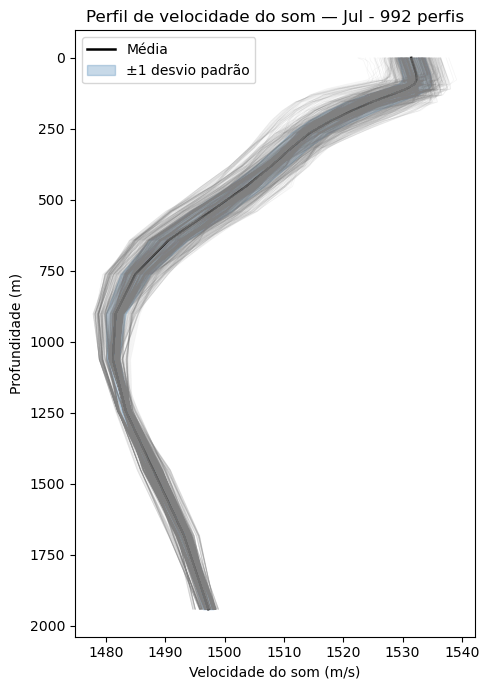

In [64]:
c_std = C.std(axis=1)          # desvio padrão por profundidade
c_mean_1d = c_mean.ravel()
 
fig3, ax3 = plt.subplots(figsize=(5, 7))
ax3.plot(c_mean_1d, depths, color="black", linewidth=1.8, label="Média")
ax3.fill_betweenx(depths, c_mean_1d - c_std, c_mean_1d + c_std,
                   color="steelblue", alpha=0.3, label="±1 desvio padrão")
 
# Sobrepõe todos os perfis individuais bem sutis, para dar noção da
# dispersão real (comente se ficar poluído com muitos anos)
for i in range(N):
    ax3.plot(C[:, i], depths, color="gray", alpha=0.08, linewidth=0.5)
 
ax3.invert_yaxis()
ax3.set_xlabel("Velocidade do som (m/s)")
ax3.set_ylabel("Profundidade (m)")
ax3.set_title(f"Perfil de velocidade do som — "+MES_ALVO+" - "+str(N)+" perfis")
ax3.legend()
fig3.tight_layout()


### PERFIL MÉDIO DE DENSIDADE +/- DESVIO PADRÃO

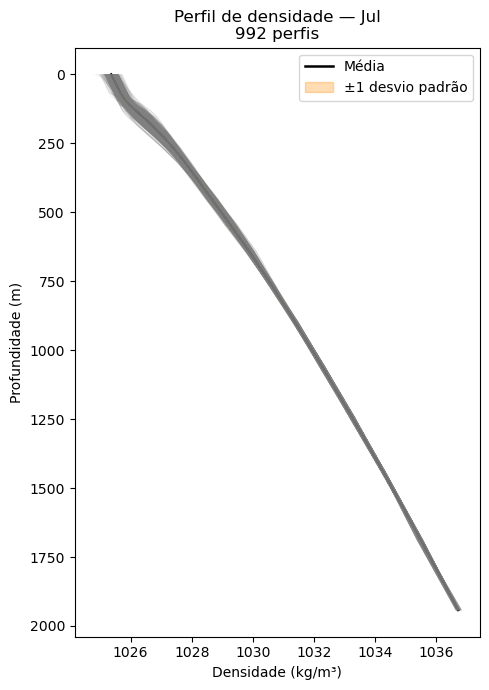

In [66]:
density_all = np.stack(df["density"].to_numpy())   # N x K (antes da limpeza)
 
density_matrix = pd.DataFrame(
    density_all.T, index=depths_grid, columns=dates_all
).sort_index()
 
# Alinha exatamente com as mesmas profundidades e datas que sobraram
# depois da limpeza feita para sound_speed (seção 2), para os dois
# perfis (som e densidade) ficarem consistentes entre si.
density_matrix = density_matrix.loc[depths, dates]
 
C_dens = density_matrix.values     # K x N
 
dens_mean = C_dens.mean(axis=1)
dens_std = C_dens.std(axis=1)
 
fig4, ax4 = plt.subplots(figsize=(5, 7))
ax4.plot(dens_mean, depths, color="black", linewidth=1.8, label="Média")
ax4.fill_betweenx(depths, dens_mean - dens_std, dens_mean + dens_std,
                   color="darkorange", alpha=0.3, label="±1 desvio padrão")
 
for i in range(N):
    ax4.plot(C_dens[:, i], depths, color="gray", alpha=0.08, linewidth=0.5)
 
ax4.invert_yaxis()
ax4.set_xlabel("Densidade (kg/m³)")
ax4.set_ylabel("Profundidade (m)")
ax4.set_title(f"Perfil de densidade — {MES_ALVO}\n{N} perfis")
ax4.legend()
fig4.tight_layout()

## 4. Matriz de covariância R (Eq. 2 e 3 do artigo)

In [42]:
R = (dC @ dC.T) / N   # K x K

## 5. Autovalores / autovetores = EOFs (Eq. 4–5 do artigo)

In [45]:
eigvals, eigvecs = np.linalg.eigh(R)     # R é simétrica -> eigh é estável
order = np.argsort(eigvals)[::-1]        # ordem decrescente
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]              # cada coluna é uma EOF (U_k)
 
cum_var = 100 * np.cumsum(eigvals) / np.sum(eigvals)
 
tabela_eof = pd.DataFrame({
    "EOF": np.arange(1, len(eigvals) + 1),
    "Autovalor": eigvals,
    "Variância acumulada (%)": cum_var,
})
print("\n--- Tabela análoga à Tabela II do artigo ---")
print(tabela_eof.head(15).to_string(index=False))


--- Tabela análoga à Tabela II do artigo ---
 EOF  Autovalor  Variância acumulada (%)
   1 189.053531                68.171357
   2  54.863942                87.954905
   3  15.714618                93.621484
   4   6.119022                95.827960
   5   3.360349                97.039678
   6   2.177601                97.824905
   7   1.762319                98.460385
   8   1.280030                98.921954
   9   0.744407                99.190382
  10   0.518288                99.377273
  11   0.360212                99.507163
  12   0.308684                99.618472
  13   0.222748                99.698793
  14   0.192167                99.768087
  15   0.163027                99.826874


## 6. Escolher G (número de EOFs retidos)

No artigo, G = 6 explicava 99.95%. Com dado diário isso pode mudar.

In [47]:
LIMIAR = 97.5  # ajuste conforme desejado
G = int(np.argmax(cum_var >= LIMIAR) + 1)
print(f"\nG = {G} EOFs explicam {cum_var[G-1]:.3f}% da variância "
      f"(limiar definido: {LIMIAR}%)")
 
U = eigvecs[:, :G]        # K x G  -> EOFs retidas


G = 6 EOFs explicam 97.825% da variância (limiar definido: 97.5%)


## 7. Coeficientes dos EOFs para cada perfil (Eq. 5 do artigo, $A_n$)

In [49]:
A = U.T @ dC               # G x N  -> A[:, n] são os coeficientes do dia n
coef_df = pd.DataFrame(
    A.T, index=pd.to_datetime(dates),
    columns=[f"A{i+1}" for i in range(G)]
)
coef_df.index.name = "date"
coef_df.head()

,A1,A2,A3,A4,A5,A6
date,,,,,,
1993-07-01 12:00:00,-4.126154,-3.039364,0.406490,2.204639,0.780241,2.901373
1993-07-02 12:00:00,-4.619383,-3.388693,0.051003,2.537868,0.782429,2.936828
1993-07-03 12:00:00,-4.337973,-4.042528,-0.531042,2.997809,0.799721,2.959525
1993-07-04 12:00:00,-3.815633,-4.347367,-1.418311,3.692176,1.048842,2.879901
1993-07-05 12:00:00,-2.766359,-4.767194,-2.263064,4.371467,1.459270,2.731105


## 8. Reconstrução e erro (Eq. 6 do artigo)

In [50]:
C_reconstructed = c_mean + U @ A
rmse_por_perfil = np.sqrt(np.mean((C - C_reconstructed) ** 2, axis=0))
print(f"RMSE médio de reconstrução com G={G} EOFs: "
      f"{rmse_por_perfil.mean():.4f} m/s "
      f"(máx: {rmse_por_perfil.max():.4f} m/s)")

RMSE médio de reconstrução com G=6 EOFs: 0.3726 m/s (máx: 0.9588 m/s)


## 9. Plot dos 6 primeiros EOFs (equivalente à Fig. 8 do artigo)

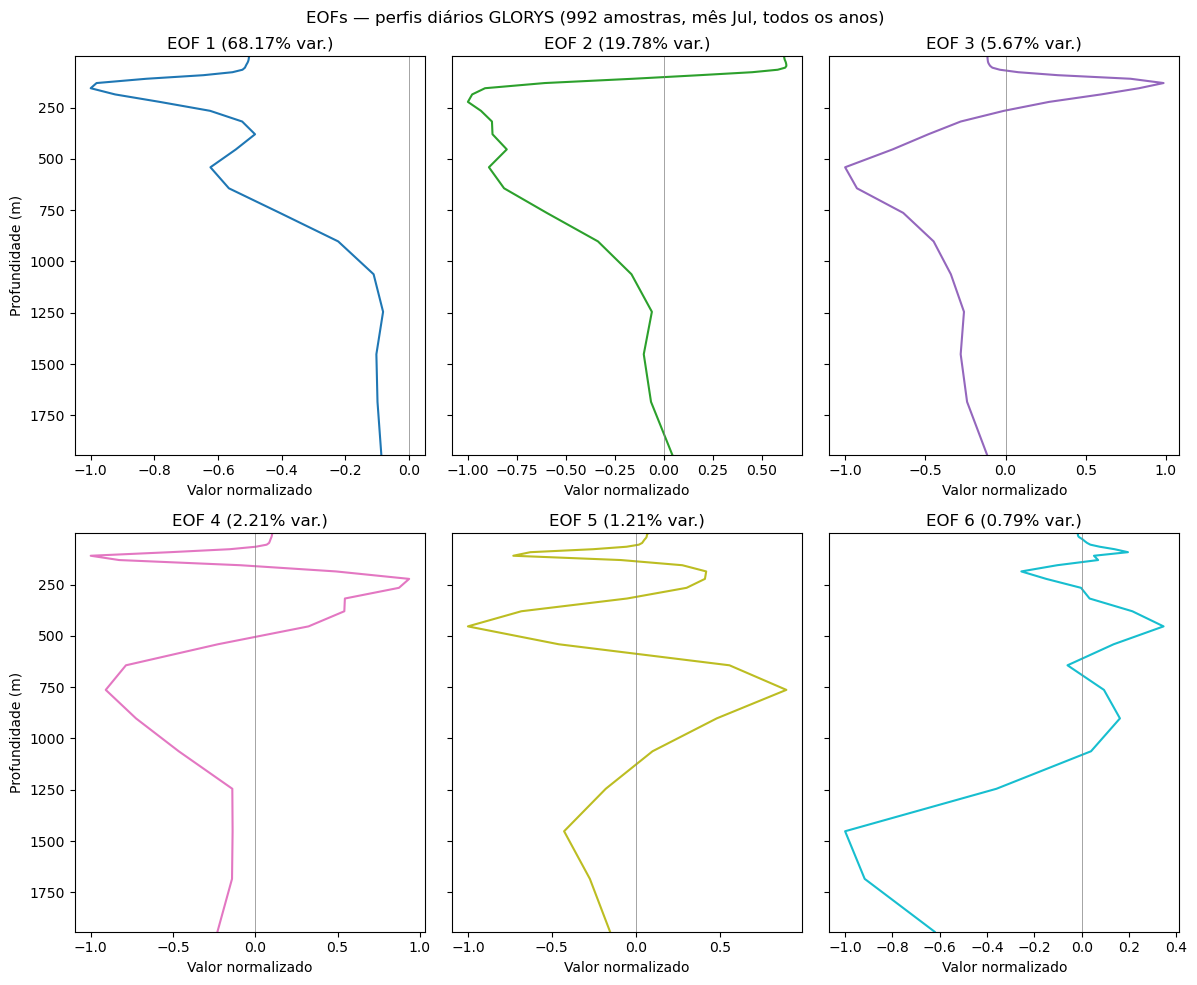

In [58]:

n_plot = min(6, G, eigvecs.shape[1])
n_cols = 3
n_rows = int(np.ceil(n_plot / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows),
                          sharey=True)
axes = np.atleast_1d(axes).ravel()
 
titulo_periodo = f"mês {MES_ALVO}, todos os anos" if MES_ALVO is not None else "1993–2026, todos os meses"
cor_var = plt.cm.tab10(np.linspace(0, 1, n_plot))
 
for i in range(n_plot):
    ax = axes[i]
    eof_norm = eigvecs[:, i] / np.max(np.abs(eigvecs[:, i]))
    ax.plot(eof_norm, depths, color=cor_var[i])
    ax.axvline(0, color="gray", linewidth=0.5)
    #ax.invert_yaxis()
    ax.set_title(f"EOF {i+1} ({cum_var[i] - (cum_var[i-1] if i > 0 else 0):.2f}% var.)")
    ax.set_xlabel("Valor normalizado")
    ax.set_ylim(depths[-1],depths[0])

    if i % n_cols == 0:
        ax.set_ylabel("Profundidade (m)")
 
# apaga eixos sobrando, se n_plot não preencher a grade
for j in range(n_plot, len(axes)):
    fig.delaxes(axes[j])
 
fig.suptitle(f"EOFs — perfis diários GLORYS ({N} amostras, {titulo_periodo})")
fig.tight_layout()
fig.savefig("eofs_glorys.png", dpi=150)

## 10. Série temporal do coeficiente A1

No artigo, A1 ~ deslocamento vertical da termoclina.

- Se `MES_ALVO` estiver definido: mostra só a variabilidade **interanual** daquele mês (ano a ano), útil para contextualizar o(s) ano(s) em que os dados sísmicos foram coletados.
- Se `MES_ALVO = None`: mostra sazonal + interanual juntos.

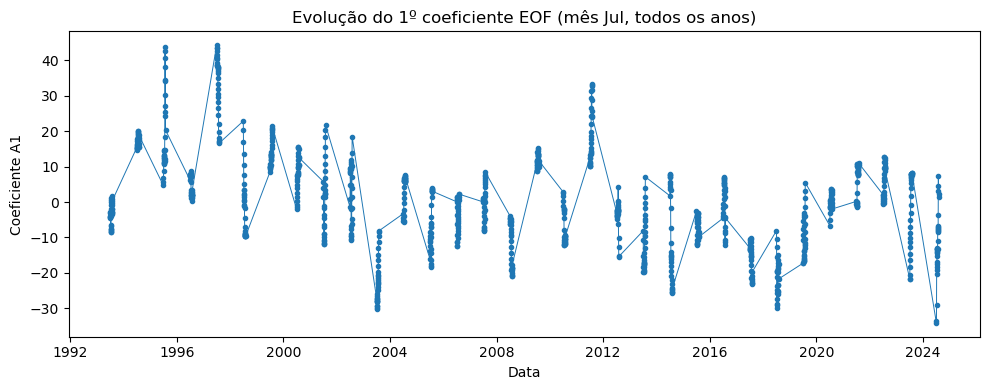

In [59]:
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(coef_df.index, coef_df["A1"], marker="o", markersize=3, linewidth=0.7)
ax2.set_xlabel("Data")
ax2.set_ylabel("Coeficiente A1")
ax2.set_title(f"Evolução do 1º coeficiente EOF ({titulo_periodo})")
fig2.tight_layout()
fig2.savefig("A1_timeseries.png", dpi=150)

## 11. Climatologia dos coeficientes

- `MES_ALVO` definido: agrupa por **ano** → variabilidade interanual daquele mês específico (o que interessa para os dados sísmicos).
- `MES_ALVO = None`: agrupa por **mês** → análogo direto à Tabela III do artigo (climatologia sazonal, N=12).

In [60]:
if MES_ALVO is not None:
    coef_df["year"] = coef_df.index.year
    resumo = coef_df.groupby("year").mean(numeric_only=True)
    print(f"\n--- Média interanual dos coeficientes EOF para o mês {MES_ALVO} "
          f"(ano a ano) ---")
else:
    coef_df["month"] = coef_df.index.month.map(lambda m: MESES_ORDEM[m - 1])
    resumo = coef_df.groupby("month").mean(numeric_only=True).reindex(MESES_ORDEM)
    print("\n--- Climatologia mensal dos coeficientes EOF (análogo à Tabela III) ---")
 
print(resumo.round(3).to_string())


--- Média interanual dos coeficientes EOF para o mês Jul (ano a ano) ---
          A1      A2     A3     A4     A5     A6
year                                            
1993  -3.346  -3.956  1.007  1.844  1.260  2.522
1994  17.098  -4.659  1.086  1.505  1.174  0.725
1995  19.162  -0.757 -0.021 -0.608 -0.922  1.823
1996   4.312  -3.630  7.053 -1.302  0.730  2.567
1997  33.190   7.568 -2.491  1.575  2.051  0.291
1998  -0.491  -2.131  5.584  3.731  0.517  0.455
1999  13.950   5.745  8.282 -1.497 -0.701 -0.846
2000   8.235   4.446  6.005  1.734 -1.023 -0.477
2001   1.103   3.779  1.783  1.708 -2.717  0.178
2002   2.670  15.521 -1.702  2.129  1.639 -0.490
2003 -22.151   1.977  3.584  2.347  0.204  0.589
2004   3.421   4.314  0.409  1.318 -0.761  0.219
2005  -6.852   6.679 -2.520 -1.530 -1.165  1.200
2006  -4.128  -5.030 -2.753 -1.480  2.960 -0.862
2007   0.069  -2.190 -3.975 -2.622  1.481  0.690
2008 -11.741  -9.340  4.585  2.441  2.674 -0.190
2009  11.814   0.617 -2.914 -0.663  0.246  1